# 03 - Preprocessing: power-line interference cancellation

Goal: implement the second signal-cleaning step. We start from `S2`, the signal already corrected for baseline wander, and remove the periodic electrical mains disturbance to obtain `S3`.

## Simple idea

The electrical grid in Italy/Europe oscillates at 50 Hz. During an ECG recording, this oscillation can leak into the signal as a regular repetitive noise. It is not a heartbeat: it is an external disturbance.

To remove it, we estimate how much 50 Hz wave is present in the signal. We do the same for 100 Hz and 150 Hz, which are multiples of the main disturbance. Then we subtract these waves from the signal.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import importlib
import numpy as np
import matplotlib.pyplot as plt
import data_io
import preprocessing
import plotting

# Reload local modules so Jupyter picks up code changes without
# requiring a full kernel restart during development.
importlib.reload(data_io)
importlib.reload(preprocessing)
importlib.reload(plotting)

from data_io import load_record
from preprocessing import remove_baseline_wander, remove_powerline_interference
from plotting import (
    plot_powerline_removal_comparison,
    plot_powerline_zoom_detail,
    plot_power_spectrum_comparison,
)


## Load the record and rebuild S2

`S1` is the raw signal. First we repeat the step from notebook 02 to obtain `S2`. This makes the notebook runnable on its own.

In [2]:
record = load_record('a14')
S1 = record.signals

baseline_result = remove_baseline_wander(
    S1,
    fs=record.fs,
    cutoff_hz=3.0,
    numtaps=1001,
)
S2 = baseline_result.filtered_signals

print(f'Record: {record.name}')
print(f'S1 shape: {S1.shape}')
print(f'S2 shape: {S2.shape}')
print(f'Sampling frequency: {record.fs:.0f} Hz')


Record: a14
S1 shape: (60000, 4)
S2 shape: (60000, 4)
Sampling frequency: 1000 Hz


## Apply power-line interference cancellation

Here we go from `S2` to `S3`. The code looks for regular waves at 50 Hz, 100 Hz, and 150 Hz. These waves are treated as interference and subtracted.

In [3]:
powerline_result = remove_powerline_interference(
    S2,
    fs=record.fs,
    frequencies_hz=(50.0, 100.0, 150.0),
)
S3 = powerline_result.cleaned_signals

print(f'S3 shape: {S3.shape}')
print(f'Frequencies removed: {powerline_result.frequencies_hz} Hz')


S3 shape: (60000, 4)
Frequencies removed: (50.0, 100.0, 150.0) Hz


## How much interference was removed?

We compute a simple measure: the RMS value. The formula is not the key point here: the larger the value, the more that component contributes to the signal. We compare the RMS of `S2` with the RMS of the estimated interference only.

In [4]:
signal_rms = np.sqrt(np.mean(S2**2, axis=0))
removed_rms = np.sqrt(np.mean(powerline_result.estimated_interference**2, axis=0))
relative_percent = 100 * removed_rms / signal_rms

for channel_name, sig, rem, rel in zip(record.channels, signal_rms, removed_rms, relative_percent):
    print(f'{channel_name}: signal RMS={sig:.3f}, removed RMS={rem:.3f}, removed={rel:.3f}%')

powerline_channel = int(np.argmax(relative_percent))
print(f'Most useful channel to display: {record.channels[powerline_channel]}')


AECG1: signal RMS=20.595, removed RMS=0.005, removed=0.026%
AECG2: signal RMS=15.901, removed RMS=0.015, removed=0.096%
AECG3: signal RMS=8.208, removed RMS=0.157, removed=1.908%
AECG4: signal RMS=15.057, removed RMS=0.007, removed=0.046%
Most useful channel to display: AECG3


## Frequency-domain plot

This plot helps us inspect the 50 Hz disturbance and its multiples. We use the channel where the estimated interference has the largest relative weight, because this makes the step easier to explain visually.

`S2` and `S3` can be almost perfectly overlapped. In the plot, `S2` is drawn as a dashed gray line so the overlap is visible instead of being hidden by the green `S3` line.

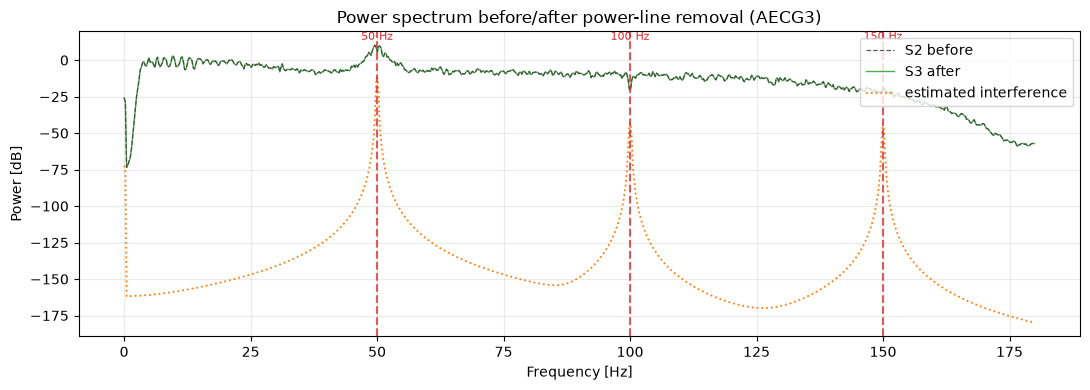

In [5]:
fig, ax = plot_power_spectrum_comparison(
    S2,
    S3,
    fs=record.fs,
    channel_name=record.channels[powerline_channel],
    channel=powerline_channel,
    target_frequencies=powerline_result.frequencies_hz,
    removed_interference=powerline_result.estimated_interference,
    save_path=PROJECT_ROOT / 'figures' / 'notebook03' / 'a14_powerline_spectrum_strongest_channel.png',
)
plt.show()


## Zoomed time-domain detail

This figure explains why `S2` and `S3` look almost identical in the large time-domain plots. The top panel shows `S2` and `S3` on the real ECG amplitude scale. The bottom panel shows only the estimated interference on its own smaller scale.

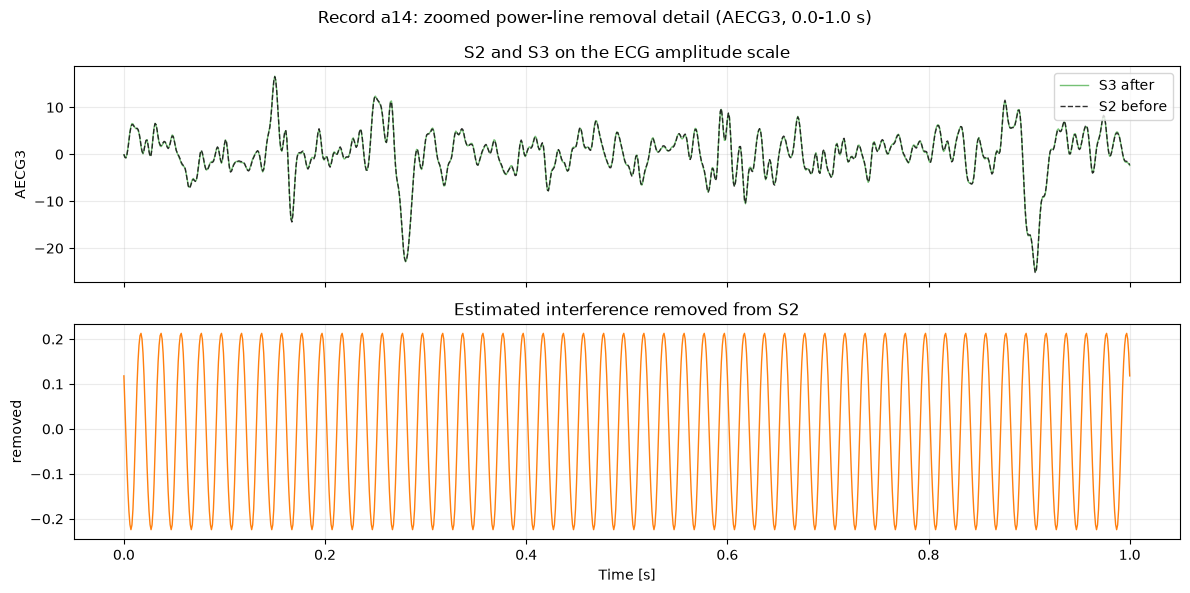

In [6]:
fig, axes = plot_powerline_zoom_detail(
    record,
    S2,
    S3,
    powerline_result.estimated_interference,
    channel=powerline_channel,
    seconds=(0, 1),
    save_path=PROJECT_ROOT / 'figures' / 'notebook03' / 'a14_powerline_zoom_detail_strongest_channel_0_1s.png',
)
plt.show()


## Time-domain comparison: first 10 seconds

Here we inspect the signal as a time series. The gray line is `S2`; the green line is `S3`. The difference can be small by eye, because the 50 Hz disturbance is often subtle. For this reason, the frequency-domain plot is more useful to show the removal effect.

If the dashed gray `S2` line and the green `S3` line overlap, it means that the correction is small compared with the ECG peaks.

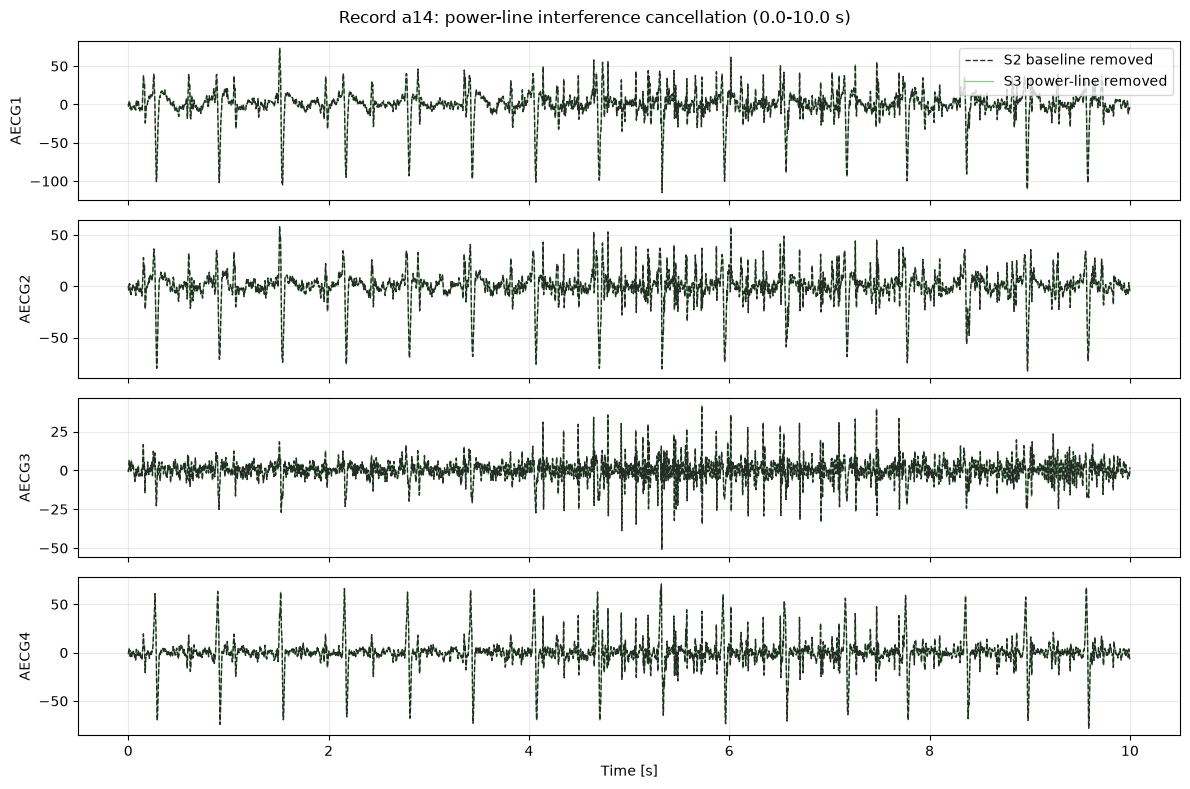

In [7]:
fig, axes = plot_powerline_removal_comparison(
    record,
    S2,
    S3,
    seconds=(0, 10),
    save_path=PROJECT_ROOT / 'figures' / 'notebook03' / 'a14_s2_s3_powerline_comparison_0_10s.png',
)
plt.show()


## Time-domain comparison: full record

This view shows the full one-minute recording. It is useful as a general check and as a summary figure for the documentation.

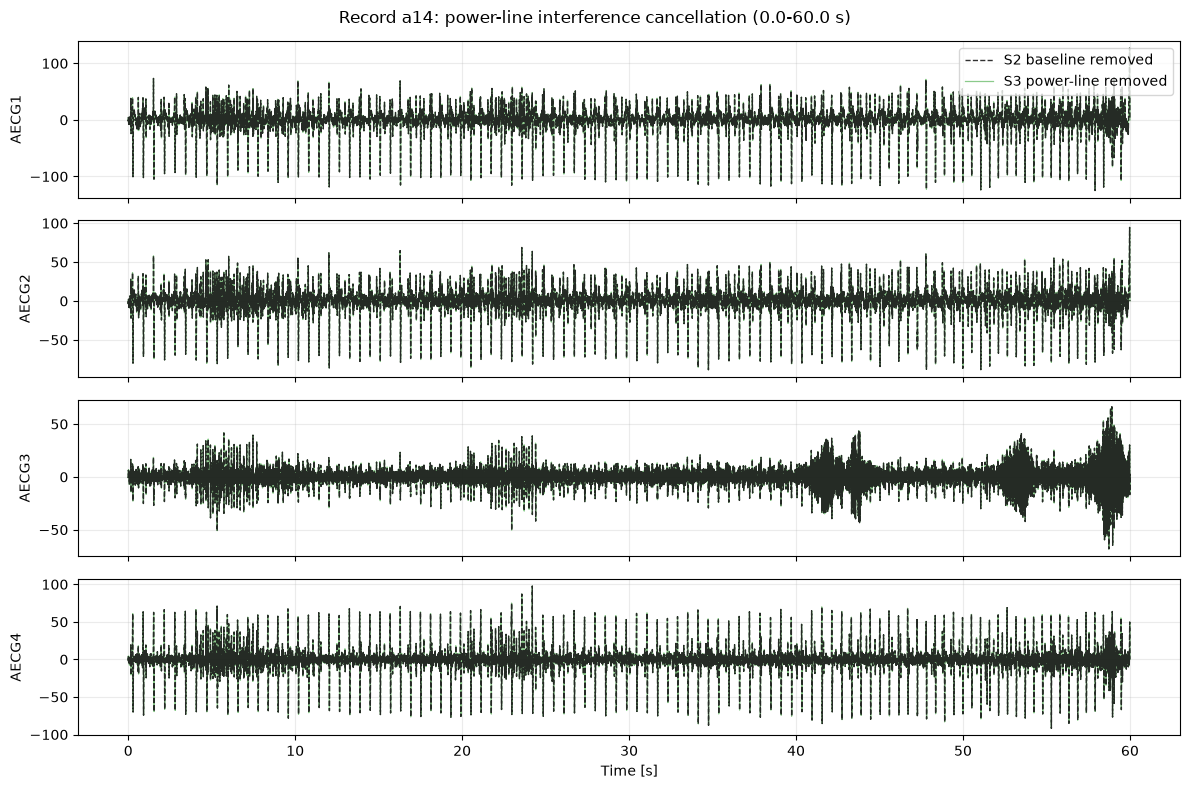

In [8]:
fig, axes = plot_powerline_removal_comparison(
    record,
    S2,
    S3,
    seconds=(0, record.time[-1]),
    save_path=PROJECT_ROOT / 'figures' / 'notebook03' / 'a14_s2_s3_powerline_comparison_full.png',
)
plt.show()


## Output of this step

`S3` is the signal after two cleaning steps: baseline wander removal and power-line interference cancellation. The next step will prepare the signal to better detect and subtract the maternal ECG.